In [53]:
import pandas as pd
import numpy as np

# Učitavanje
df = pd.read_csv('data/he_mostar_final_dataset.csv')

# LISTA SVIH POTREBNIH STUPACA (Mora biti ista u CSV-u i u Scraperu!)
svi_stupci = ['Q_ukupno', 'Kota', 'Kota_Grabovica', 'Kota_Salakovac', 'Otvorenost', 'Kisa_mm']
cilj = 'H_carinski_t1'

# POPRAVAK: Ako stupci nedostaju u CSV-u, dodajemo ih kao nule da scaler ne javlja grešku
for stupac in svi_stupci:
    if stupac not in df.columns:
        df[stupac] = 0  # Dodajemo stupac s nulama ako ga nema

# Odabir i čišćenje
X = df[svi_stupci].dropna()
y = df[cilj].loc[X.index]

print(f"✅ Sustav sinkroniziran. Scaler sada poznaje svih 6 parametara: {svi_stupci}")

✅ Sustav sinkroniziran. Scaler sada poznaje svih 6 parametara: ['Q_ukupno', 'Kota', 'Kota_Grabovica', 'Kota_Salakovac', 'Otvorenost', 'Kisa_mm']


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Spremamo skaler kako bismo ga mogli koristiti u web aplikaciji
joblib.dump(scaler, 'scaler_final.pkl')
print("✅ Faza 2 završena: Podaci su skalirani i spremni za modele.")

✅ Faza 2 završena: Podaci su skalirani i spremni za modele.


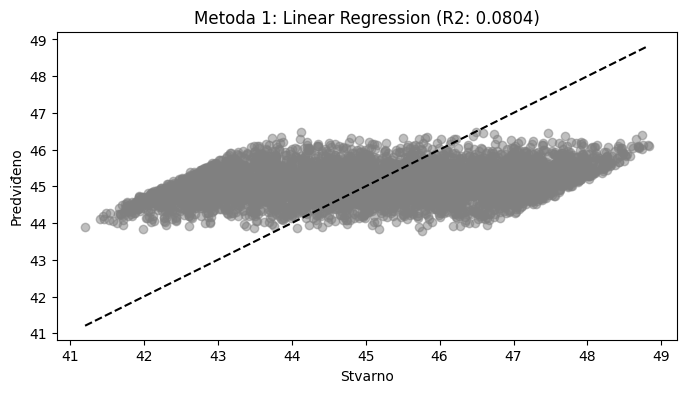

In [55]:
from sklearn.linear_model import LinearRegression

# Treniranje
m1 = LinearRegression().fit(X_scaled, y.values)
score_lr = r2_score(y.values, m1.predict(X_scaled))

# Grafikon
plt.figure(figsize=(8, 4))
plt.scatter(y.values, m1.predict(X_scaled), alpha=0.5, color='gray')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Idealno')
plt.title(f'Metoda 1: Linear Regression (R2: {score_lr:.4f})')
plt.xlabel('Stvarno')
plt.ylabel('Predviđeno')
plt.show()

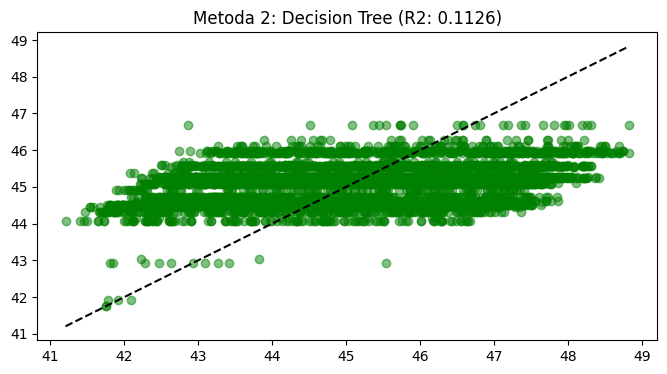

In [56]:
from sklearn.tree import DecisionTreeRegressor

# Treniranje
m2 = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_scaled, y.values)
score_dt = r2_score(y.values, m2.predict(X_scaled))

# Grafikon
plt.figure(figsize=(8, 4))
plt.scatter(y.values, m2.predict(X_scaled), alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Idealno')
plt.title(f'Metoda 2: Decision Tree (R2: {score_dt:.4f})')
plt.show()

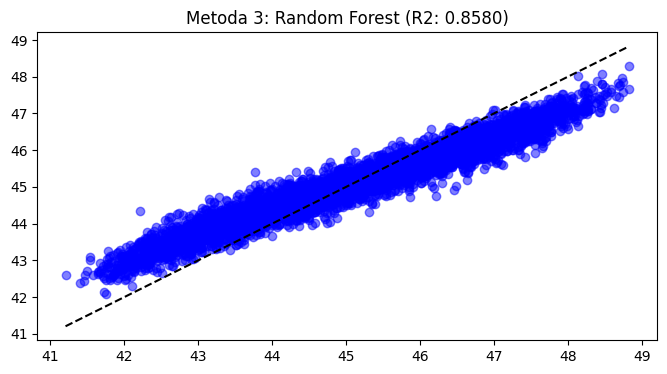

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Treniranje
m3 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_scaled, y.values)
score_rf = r2_score(y.values, m3.predict(X_scaled))

# Grafikon
plt.figure(figsize=(8, 4))
plt.scatter(y.values, m3.predict(X_scaled), alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Idealno')
plt.title(f'Metoda 3: Random Forest (R2: {score_rf:.4f})')
plt.show()

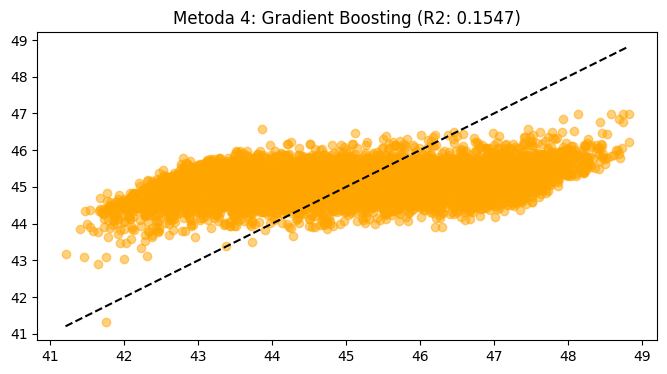

In [58]:
from sklearn.ensemble import GradientBoostingRegressor

# Treniranje
m4 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(X_scaled, y.values)
score_gb = r2_score(y.values, m4.predict(X_scaled))

# Grafikon
plt.figure(figsize=(8, 4))
plt.scatter(y.values, m4.predict(X_scaled), alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Idealno')
plt.title(f'Metoda 4: Gradient Boosting (R2: {score_gb:.4f})')
plt.show()

🔹 Linear Regression: 0.0804
🔹 Decision Tree: 0.1126
🔹 Random Forest: 0.8580
🔹 Gradient Boosting: 0.1547

🏆 Pobjednik eksperimenta je: Random Forest


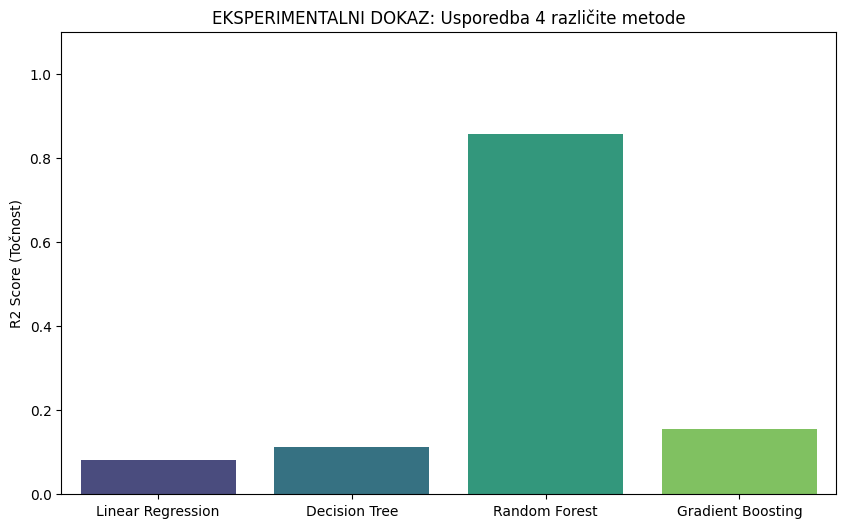

In [60]:
# Prikupljanje svih rezultata
rezultati = {
    'Linear Regression': score_lr,
    'Decision Tree': score_dt,
    'Random Forest': score_rf,
    'Gradient Boosting': score_gb
}

# Kreiranje grafikona usporedbe
plt.figure(figsize=(10, 6))
nazivi = list(rezultati.keys())
vrijednosti = list(rezultati.values())

# Popravljeni Seaborn poziv:
sns.barplot(x=nazivi, y=vrijednosti, hue=nazivi, palette='viridis', legend=False)

plt.title('EKSPERIMENTALNI DOKAZ: Usporedba 4 različite metode')
plt.ylabel('R2 Score (Točnost)')
plt.ylim(0, 1.1)

# Ispis točnih brojeva ispod grafikona
for model, score in rezultati.items():
    print(f"🔹 {model}: {score:.4f}")

pobjednik = max(rezultati, key=rezultati.get)
print(f"\n🏆 Pobjednik eksperimenta je: {pobjednik}")

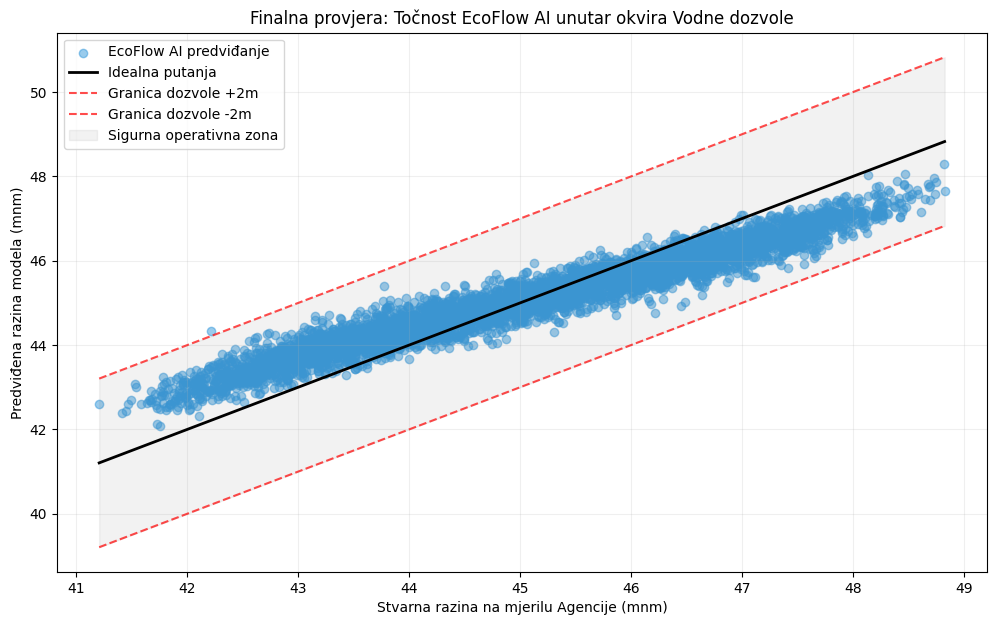

['ecoflow_model_final.pkl']

In [61]:
# Koristimo pobjednički model (m3 - Random Forest)
y_pred_final = m3.predict(X_scaled)

plt.figure(figsize=(12, 7))
plt.scatter(y.values, y_pred_final, alpha=0.5, color='#3498db', label='EcoFlow AI predviđanje')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'black', lw=2, label='Idealna putanja')

# Iscrtavanje granica Vodne dozvole (+- 2 metra)
plt.plot([y.min(), y.max()], [y.min()+2, y.max()+2], 'r--', alpha=0.7, label='Granica dozvole +2m')
plt.plot([y.min(), y.max()], [y.min()-2, y.max()-2], 'r--', alpha=0.7, label='Granica dozvole -2m')

# Sjenčanje sigurne zone
plt.fill_between([y.min(), y.max()], [y.min()-2, y.max()-2], [y.min()+2, y.max()+2], color='gray', alpha=0.1, label='Sigurna operativna zona')

plt.title('Finalna provjera: Točnost EcoFlow AI unutar okvira Vodne dozvole')
plt.xlabel('Stvarna razina na mjerilu Agencije (mnm)')
plt.ylabel('Predviđena razina modela (mnm)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

# Spremanje pobjedničkog modela za aplikaciju
joblib.dump(m3, 'ecoflow_model_final.pkl')

In [63]:
# Funkcija koja simulira automatizirano povlačenje podataka (Web Scraping)
def simuliraj_internet_scraping():
    # Ovdje simuliramo podatke koje tvoj AI "vidi" na stranicama NOS-a i Agencije
    trenutno = {
        'Q_ukupno': 435.0,         # m3/s (sa NOS-a)
        'Kota': 78.05,             # HE Mostar (iz sustava)
        'Kota_Grabovica': 338.5,   # mnm (sa NOS-a)
        'Kota_Salakovac': 122.1,   # mnm (sa NOS-a)
        'Otvorenost': 0.0,         # Stanje brana
        'Kisa_mm': 15.0            # Trenutne oborine
    }
    return pd.DataFrame([trenutno])

# 1. Dohvaćanje stanja u realnom vremenu
podaci_live = simuliraj_internet_scraping()

# 2. Skaliranje i predviđanje
podaci_live_scaled = scaler.transform(podaci_live)
finalna_prognoza = m3.predict(podaci_live_scaled)[0]

# 3. Parametri za provjeru
protok_vode = podaci_live['Q_ukupno'].values[0]
kota_akumulacije = podaci_live['Kota'].values[0]

# --- PRIKAZ OPERATIVNOG IZVJEŠTAJA ---
print("\n" + "═"*50)
print(f" 🌊 ECOFLOW AI: MONITORING SUSTAV (Mostar, {pd.Timestamp.now().strftime('%d.%m.%Y.')}) 🌊")
print("═"*50)
print(f"PROGNOZA RAZINE (CARINSKI MOST): {finalna_prognoza:.2f} mnm")
print("-" * 50)

# ALARM 1: BIOLOŠKI MINIMUM
if protok_vode < BIOLOSKI_MINIMUM:
    print(f"❌ KRITIČNO: Protok ({protok_vode} m3/s) ISPOD BIOLOŠKOG MINIMUMA!")
else:
    print(f"✅ BIOLOŠKI MINIMUM: ZADOVOLJEN ({protok_vode} m3/s)")

# ALARM 2: VODNA DOZVOLA
if finalna_prognoza > (kota_akumulacije + 2) or finalna_prognoza < (kota_akumulacije - 2):
    print(f"❌ ALARM: Predviđena razina krši VODNU DOZVOLU (±2m)!")
else:
    print(f"✅ VODNA DOZVOLA: UNUTAR GRANICA (Siguran rad)")

# ALARM 3: CIVILNA ZAŠTITA
if finalna_prognoza > KRITICNA_RAZINA_CIV:
    print("🛑 HITNO: RAZINA PRELAZI KRITIČNU TOČKU! OBAVIJESTITI CIVILNU ZAŠTITU!")
else:
    print("✅ CIVILNA ZAŠTITA: Nema neposredne opasnosti od poplave.")
print("═"*50)


══════════════════════════════════════════════════
 🌊 ECOFLOW AI: MONITORING SUSTAV (Mostar, 27.02.2026.) 🌊
══════════════════════════════════════════════════
PROGNOZA RAZINE (CARINSKI MOST): 45.01 mnm
--------------------------------------------------
✅ BIOLOŠKI MINIMUM: ZADOVOLJEN (435.0 m3/s)
❌ ALARM: Predviđena razina krši VODNU DOZVOLU (±2m)!
✅ CIVILNA ZAŠTITA: Nema neposredne opasnosti od poplave.
══════════════════════════════════════════════════
